# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://portfoliooptimization.org)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__

## Tutorial 25: Constraints on Maximum Numbers of Assets

## 1. Downloading the data:

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2016-01-01'
end = '2019-12-30'

# Tickers of assets
assets = ['JCI', 'TGT', 'CMCSA', 'CPB', 'MO', 'APA', 'MRSH', 'JPM',
          'ZION', 'PSA', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
          'DE', 'MSFT', 'HPQ', 'SHW', 'VZ', 'CNP', 'NI', 'T', 'BA']
assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  25 of 25 completed


In [2]:
# Calculating returns

Y = data[assets].pct_change().dropna()

display(Y.head())

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-2.0257%,0.4057%,0.4036%,1.9693%,0.0180%,0.9305%,0.3678%,0.5783%,0.9482%,-1.1953%,...,1.5881%,0.0212%,2.8236%,0.4044%,0.6986%,1.7539%,-0.1729%,0.2409%,1.3734%,-1.0858%
2016-01-06,-11.4863%,-1.5879%,0.2411%,-1.7557%,-0.7727%,-1.2473%,-0.1736%,-1.1239%,-3.5866%,-0.9551%,...,0.5548%,0.0212%,0.1592%,-2.8931%,0.3108%,-1.0155%,-0.7653%,-3.0048%,-0.9034%,-2.9145%
2016-01-07,-5.1389%,-4.1922%,-1.6573%,-2.7699%,-1.1047%,-1.9769%,-1.2206%,-0.8856%,-4.6059%,-2.5394%,...,-2.2066%,-3.0309%,-1.0410%,-2.7418%,-1.6148%,-0.2700%,-2.2845%,-2.0570%,-0.5492%,-3.0019%
2016-01-08,0.2736%,-2.2705%,-1.6037%,-2.5425%,0.1099%,-0.2241%,0.5706%,-1.6402%,-1.7642%,-0.1649%,...,-0.1538%,-1.1366%,-0.7308%,0.0828%,0.0895%,-3.3838%,-0.1117%,-1.1387%,-0.9719%,-1.1254%
2016-01-11,-4.3383%,0.1692%,-1.6851%,-1.0215%,0.0915%,-1.1791%,0.5674%,0.5287%,0.6616%,0.0330%,...,1.6436%,0.0000%,0.9870%,0.0827%,1.2224%,1.4570%,0.5367%,-0.4607%,0.5800%,-1.9918%


## 2. Estimating Mean Variance Portfolios

### 2.1 Calculating the portfolio that maximizes Sharpe ratio.

In [3]:
import riskfolio as rp

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimum portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

# Estimate optimal portfolio:

model='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'CVaR' # Risk measure used, this time will be variance
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
weights,0.0000%,0.0000%,10.9046%,0.0000%,0.0000%,12.2078%,0.0000%,0.6435%,0.0000%,0.0000%,...,13.0855%,0.0000%,0.0000%,8.2955%,0.0000%,12.0888%,0.0000%,0.0000%,3.8314%,0.0000%


### 2.2 Plotting portfolio composition

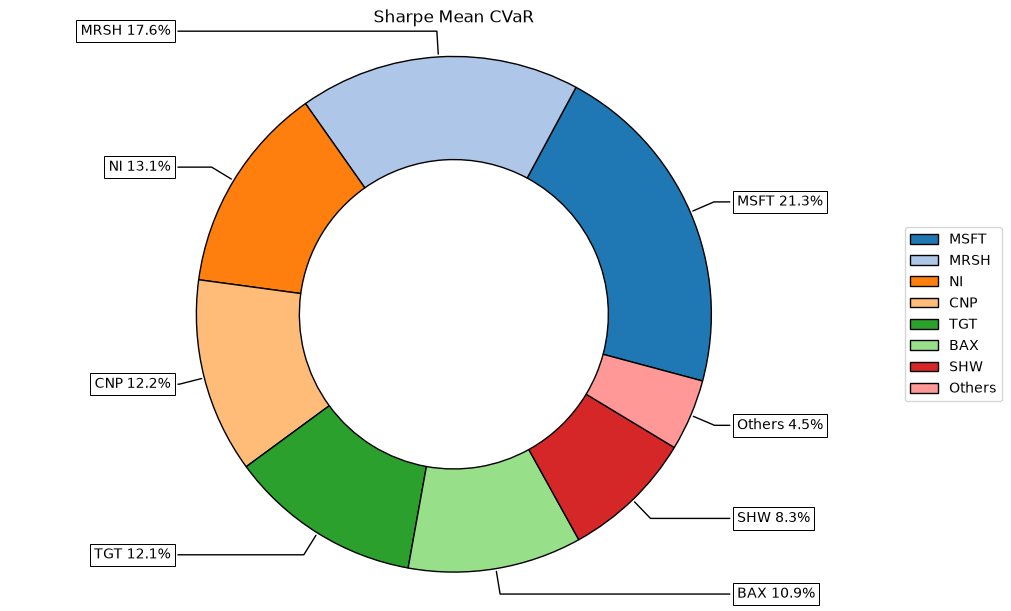

In [4]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w,
                 title='Sharpe Mean CVaR',
                 others=0.05,
                 nrow=25,
                 cmap="tab20",
                 height=6,
                 width=10,
                 ax=None)

In [5]:
# Number of assets in portfolio
n_assets = np.sum(np.where(np.round(w,4) > 0, 1, 0)).item()

# Number of effective assets in portfolio
nea = 1/np.sum(w ** 2).item()

print('Number of Assets:', n_assets)
print('Number of Effective Assets:', nea)

Number of Assets: 9
Number of Effective Assets: 6.972623423546183


### 2.3 Calculating the portfolio including a constraint on the maximum number of assets.

This kind of constraint help us to put a limit in the maximum number of assets, this could be helpful for small investors that can't afford buy too many assets.

In [6]:
# First we need to set a solver that support Mixed Integer Programming
port.solvers = ['MOSEK']

# Then we need to set the cardinality constraint (maximum number of assets)
port.card = 5

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
weights,0.0000%,0.0000%,14.6519%,0.0000%,0.0000%,25.2277%,0.0000%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,14.6290%,0.0000%,0.0000%,0.0000%,0.0000%


### 2.4 Plotting portfolio composition

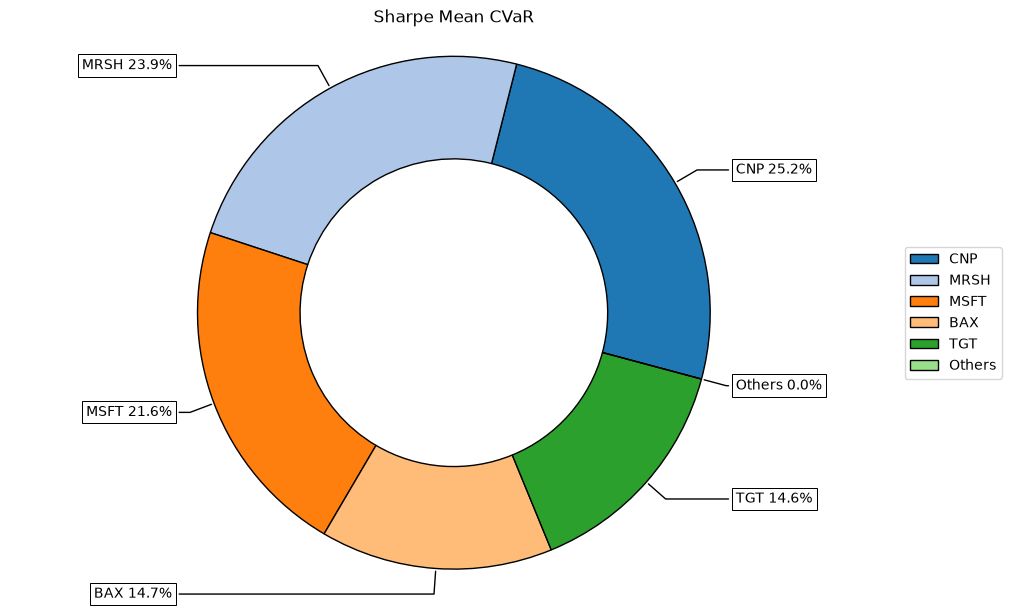

In [7]:
ax = rp.plot_pie(w=w,
                 title='Sharpe Mean CVaR',
                 others=0.05,
                 nrow=25,
                 cmap="tab20",
                 height=6,
                 width=10,
                 ax=None)

In [8]:
# Number of assets in portfolio
n_assets = np.sum(np.where(np.round(w,4) > 0, 1, 0)).item()

# Number of effective assets in portfolio
nea = 1/np.sum(w ** 2).item()

print('Number of Assets:', n_assets)
print('Number of Effective Assets:', nea)

Number of Assets: 5
Number of Effective Assets: 4.75637093193663


### 2.5 Calculating the portfolio including a constraint on the minimum number of effective assets.

This kind of constraint help us to put a limit in the minimum number of effective assets, this could be helpful to increase the portfolio diversification.

In [9]:
# First we need to delete the cardinality constraint
port.card = None 

# Then we need to set the constraint on the minimum number of effective assets
port.nea = 12

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
weights,0.0000%,5.5081%,9.9087%,0.0000%,2.1088%,8.1527%,0.1780%,4.9355%,0.0000%,0.0000%,...,10.7171%,0.0000%,0.0000%,9.3914%,1.7681%,9.9164%,4.2073%,0.0000%,7.8914%,0.0000%


### 2.6 Plotting portfolio composition

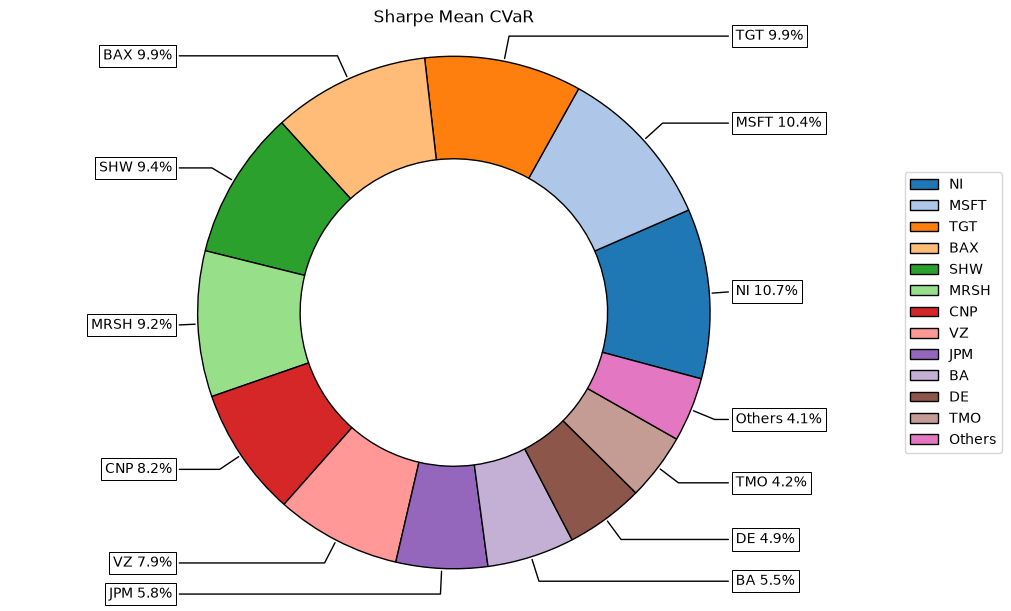

In [10]:
ax = rp.plot_pie(w=w,
                 title='Sharpe Mean CVaR',
                 others=0.05,
                 nrow=25,
                 cmap = "tab20",
                 height=6,
                 width=10,
                 ax=None)

In [11]:
# Number of assets in portfolio
n_assets = np.sum(np.where(np.round(w,4) > 0, 1, 0)).item()

# Number of effective assets in portfolio
nea = 1/np.sum(w ** 2).item()

print('Number of Assets:', n_assets)
print('Number of Effective Assets:', nea)

Number of Assets: 15
Number of Effective Assets: 12.00000000162901
